# Assignment 5
### Do all four questions.


### Sophie Kim

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [86]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [87]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [88]:
A_e_1 = A @ e_1
A_e_1

array([1, 4, 7])

*The part of the A matrix that gets selected is the first column, which would be [1, 4, 7]. This is because the first number in each row (aka the first column of A matrix) gets multiplied with the 1 value in the e_1 vector. The values in the second and third columns get multiplied with 0, so when added up, it's just the value of the first column that remains.*

In [89]:
A_e_2 = A @ e_2
A_e_2

array([2, 5, 8])

*The part of the A matrix that gets selected is the second column, which would be [2, 5, 8]. This is because the second number in each row (aka the second column of the A matrix) gets mutliplied with the 1 value in the e_2 vector. The values in the first and third columns get multiplied with 0, so when added up, it's just the value of the second column that remains.*

In [90]:
A_e_3 = A @ e_3
A_e_3

array([3, 6, 9])

*The part of the A matrix that gets selected is the third column, which would be [3, 6, 9]. This is because the third number in each row (aka the third column of the A matrix) gets multiplied with the 1 value in the e_3 vector. The values in the first and second columns get multiplied with 0, so when added up, it's just the value of the third column that remains.*

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [91]:
u = np.ones(3)
u

array([1., 1., 1.])

In [92]:
A_u = A @ u
A_u

array([ 6., 15., 24.])

*The result of this multiplication gives [6, 15, 24]. This result logically makes sense since you would sum the products for multiplying each row in the A matrix by the column vector. Since the column vector is [1, 1, 1], you are essentially summing each row in the A matrix. Thus, you get the answer [6, 15, 24].*

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [93]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [94]:
A_x = A @ x
A_x

array([-2,  4, 11])

*When A is multiplied by x, the value that is returned is the x vector. Anytime you multiply an identity matrix by any vector, you get the vector. This is because when you are multiplying each row in the matrix by the columns, the 1s line up so that the first, second, and third (and so on) values in the vector are getting multiplied by a 1 in their original place in the vector.*

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [95]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [96]:
A_x_2 = A @ x 
A_x_2

array([11, -2,  4])

*The resulting vector of [11, -2, 4] logically make sense since you are multiplying the 11 value by 1 in the first row, then the -2 value by 1, then the 4 value by 1. The rest of the values are multiplied by 0, so when summed, you get the original values from the vector, just in different order.*

In [97]:
A = np.array([ [1,0,0],
              [1,0,0],
              [0,0,1]])
x = np.array([-2,4,11])

In [98]:
A_x_3 = A @ x 
A_x_3

array([-2, -2, 11])

*In this matrix, the 1 value is in the first column for the first two rows and then in the third column for the third row. That would translate to the first value from the original vector being in the resulting vector for the first two values, and then the third value in the resulting vector being from the third value in the original vector.*

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [99]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [100]:
A_e_1 = A @ e_1
A_e_1

array([0.50052958, 0.02574731, 0.47372311])

In [101]:
A_e_2 = A @ e_2
A_e_2

array([0.24049286, 0.39251588, 0.36699127])

In [102]:
A_e_3 = A @ e_3
A_e_3

array([0.18358131, 0.37907577, 0.43734292])

*The results are similar to above, where each column from the A matrix was pulled for each respective vector multiplication. However, in this case, it can be interpreted by the Markov transition as well. The A_e_1 column vector shows the proportion of observations that started in the same initial state (say, state 1) and then went to states 1, 2, 3. The A_e_2 column vector shows the proportion of observations that started in the same initial state (say, state 2) and then went to states 1, 2, 3. The A_e_3 column vector shows the proportion of observations that started in the same initial state (say, state 3) and then went to states 1, 2, 3.*

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [103]:
current_copy = e_1.copy()
current_copy = A @ current_copy
current_copy = A @ current_copy
current_copy = A @ current_copy
current_copy = A @ current_copy
current_copy = A @ current_copy
A_e_1 = current_copy
A_e_1

array([0.29266551, 0.27862515, 0.42870935])

In [104]:
current_copy2 = e_2.copy()
current_copy2 = A @ current_copy2
current_copy2 = A @ current_copy2
current_copy2 = A @ current_copy2
current_copy2 = A @ current_copy2
current_copy2 = A @ current_copy2
A_e_2 = current_copy2
A_e_2

array([0.29197422, 0.27979983, 0.42822595])

In [105]:
current_copy3 = e_3.copy()
current_copy3 = A @ current_copy3
current_copy3 = A @ current_copy3
current_copy3 = A @ current_copy3
current_copy3 = A @ current_copy3
current_copy3 = A @ current_copy3
A_e_3 = current_copy3
A_e_3

array([0.29171646, 0.2802254 , 0.42805814])

*The results from multiplying the A matrix by the respective vectors 5 times are very similar to each other. This most likely means that no matter the starting point of the observation, the proportion of observations usually ends up in the same area.*

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


**Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?**

In [106]:
initial_cond = np.array([1,0])
initial_cond

array([1, 0])

In [107]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [108]:
p_1  = T @ initial_cond
p_1

array([0.25, 0.75])

*The [0.25, 0.75] indicates that when all observations start in state 1 (since it's from the first column, so 100% starting in state 1), 25% will stay in state 1 and 75% will go to state 2.*

**Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)**

In [109]:
p_2 = T @ p_1
print(p_2)

[0.4375 0.5625]


*This tells you that after two transitions, after 100% of the observations starting in state 1, ~44% will be in state 1 and ~56% will be in state 2.*

**Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?**

In [110]:
n = 100
p = np.array([1,0])
for t in range(n):
    print(f'step {t} : {p}')
    p = T @ p

step 0 : [1 0]
step 1 : [0.25 0.75]
step 2 : [0.4375 0.5625]
step 3 : [0.390625 0.609375]
step 4 : [0.40234375 0.59765625]
step 5 : [0.39941406 0.60058594]
step 6 : [0.40014648 0.59985352]
step 7 : [0.39996338 0.60003662]
step 8 : [0.40000916 0.59999084]
step 9 : [0.39999771 0.60000229]
step 10 : [0.40000057 0.59999943]
step 11 : [0.39999986 0.60000014]
step 12 : [0.40000004 0.59999996]
step 13 : [0.39999999 0.60000001]
step 14 : [0.4 0.6]
step 15 : [0.4 0.6]
step 16 : [0.4 0.6]
step 17 : [0.4 0.6]
step 18 : [0.4 0.6]
step 19 : [0.4 0.6]
step 20 : [0.4 0.6]
step 21 : [0.4 0.6]
step 22 : [0.4 0.6]
step 23 : [0.4 0.6]
step 24 : [0.4 0.6]
step 25 : [0.4 0.6]
step 26 : [0.4 0.6]
step 27 : [0.4 0.6]
step 28 : [0.4 0.6]
step 29 : [0.4 0.6]
step 30 : [0.4 0.6]
step 31 : [0.4 0.6]
step 32 : [0.4 0.6]
step 33 : [0.4 0.6]
step 34 : [0.4 0.6]
step 35 : [0.4 0.6]
step 36 : [0.4 0.6]
step 37 : [0.4 0.6]
step 38 : [0.4 0.6]
step 39 : [0.4 0.6]
step 40 : [0.4 0.6]
step 41 : [0.4 0.6]
step 42 : [0.4 0

*This shows that after around transitioning for the 7th time, the proportions of observations in state 1 and state 2 are basically constant. They reach consistently constant at step 14. This means that 100% of the population that starts in state 1 usually ends up 40% still in state 1 and 60% in state 2.*

**Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?**

In [111]:
n = 100
p = np.array([0,1])
for t in range(n):
    print(f'step {t} : {p}')
    p = T @ p

step 0 : [0 1]
step 1 : [0.5 0.5]
step 2 : [0.375 0.625]
step 3 : [0.40625 0.59375]
step 4 : [0.3984375 0.6015625]
step 5 : [0.40039062 0.59960938]
step 6 : [0.39990234 0.60009766]
step 7 : [0.40002441 0.59997559]
step 8 : [0.3999939 0.6000061]
step 9 : [0.40000153 0.59999847]
step 10 : [0.39999962 0.60000038]
step 11 : [0.4000001 0.5999999]
step 12 : [0.39999998 0.60000002]
step 13 : [0.40000001 0.59999999]
step 14 : [0.4 0.6]
step 15 : [0.4 0.6]
step 16 : [0.4 0.6]
step 17 : [0.4 0.6]
step 18 : [0.4 0.6]
step 19 : [0.4 0.6]
step 20 : [0.4 0.6]
step 21 : [0.4 0.6]
step 22 : [0.4 0.6]
step 23 : [0.4 0.6]
step 24 : [0.4 0.6]
step 25 : [0.4 0.6]
step 26 : [0.4 0.6]
step 27 : [0.4 0.6]
step 28 : [0.4 0.6]
step 29 : [0.4 0.6]
step 30 : [0.4 0.6]
step 31 : [0.4 0.6]
step 32 : [0.4 0.6]
step 33 : [0.4 0.6]
step 34 : [0.4 0.6]
step 35 : [0.4 0.6]
step 36 : [0.4 0.6]
step 37 : [0.4 0.6]
step 38 : [0.4 0.6]
step 39 : [0.4 0.6]
step 40 : [0.4 0.6]
step 41 : [0.4 0.6]
step 42 : [0.4 0.6]
step 43 

*Starting with 100% of the population in state 2, the results are bascially the same.*

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

**Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?**

In [112]:
import pandas as pd 

weather = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 6/cville_weather.csv")
weather

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [113]:
weather.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

*Yes, there are some missing data vlaues, particuarly in the DAPR, DAPR_ATTRIBUTES, MDPR, and MDPR_ATTRIBUTES columns.*

In [114]:
weather.dropna(subset=['PRCP'], inplace=True)
weather

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-26,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [115]:
weather.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                 0
PRCP_ATTRIBUTES      0
SNOW               176
SNOW_ATTRIBUTES    176
SNWD               398
SNWD_ATTRIBUTES    398
dtype: int64

**Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.**

In [116]:
weather['rain'] = (weather['PRCP'] > 0).astype(int)
weather['rain']

0      1
1      1
2      1
3      1
4      0
      ..
405    0
406    0
407    0
408    0
409    0
Name: rain, Length: 399, dtype: int64

**Build a two-state Markov chain over the states 0 and 1 for the `rain` variable.**

In [117]:
seq = weather['rain'].values
states = [0,1]

In [118]:
S = len(states)
T = len(seq)
tr_counts = np.zeros( (S, S) ) # from each state to another state

for t in range(1,T): # For each transition
    # Current and next tokens:
    x_tm1 = seq[t-1] # previous state
    x_t = seq[t] # current state
    # Determine transition indices:
    index_from = states.index(x_tm1)
    index_to = states.index(x_t)
    # Update transition counts:
    tr_counts[index_to, index_from] += 1


print(f'\nTransition Counts:\n {tr_counts}')

# Sum the transition counts by row:
sums = tr_counts.sum(axis=1, keepdims=True)
print(f'\nState Counts: \n {sums}')

# Sum the transition counts by row:
print(f'\nState proportions: \n {sums/np.sum(sums)}')

# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, sums, 
                            out=np.zeros_like(tr_counts), 
                            where= sums!=0)

tr_pr_1 = tr_pr # Save transition matrix for later

print(f'\nTransition Proportions:')
pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)


Transition Counts:
 [[163.  57.]
 [ 56. 122.]]

State Counts: 
 [[220.]
 [178.]]

State proportions: 
 [[0.55276382]
 [0.44723618]]

Transition Proportions:


,0,1
0,0.74,0.26
1,0.31,0.69


**For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?**

*If it was rainy yesterday, then it has a 69% chance it will rain today. If it was clear yesterday, then there is a 31% chance that it will rain today.*

**Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?**

In [119]:
T = np.array([[ 0.74, 0.26],
                 [ 0.31, 0.69 ]])

In [120]:
n = 100
p = np.array([1, 0]) # starting from clear day
for t in range(n):
    print(f'step {t} : {p}')
    p = T @ p

step 0 : [1 0]
step 1 : [0.74 0.31]
step 2 : [0.6282 0.4433]
step 3 : [0.580126 0.500619]
step 4 : [0.55945418 0.52526617]
step 5 : [0.5505653  0.53586445]
step 6 : [0.54674308 0.54042171]
step 7 : [0.54509952 0.54238134]
step 8 : [0.5443928  0.54322398]
step 9 : [0.5440889  0.54358631]
step 10 : [0.54395823 0.54374211]
step 11 : [0.54390204 0.54380911]
step 12 : [0.54387788 0.54383792]
step 13 : [0.54386749 0.5438503 ]
step 14 : [0.54386302 0.54385563]
step 15 : [0.5438611  0.54385792]
step 16 : [0.54386027 0.54385891]
step 17 : [0.54385992 0.54385933]
step 18 : [0.54385976 0.54385951]
step 19 : [0.5438597  0.54385959]
step 20 : [0.54385967 0.54385962]
step 21 : [0.54385966 0.54385964]
step 22 : [0.54385965 0.54385964]
step 23 : [0.54385965 0.54385965]
step 24 : [0.54385965 0.54385965]
step 25 : [0.54385965 0.54385965]
step 26 : [0.54385965 0.54385965]
step 27 : [0.54385965 0.54385965]
step 28 : [0.54385965 0.54385965]
step 29 : [0.54385965 0.54385965]
step 30 : [0.54385965 0.54385965

*Starting from a clear day, the forecasted distribution converges to a fixed result after about 11 steps.*

In [121]:
n = 100
p = np.array([0, 1]) # starting from rainy day
for t in range(n):
    print(f'step {t} : {p}')
    p = T @ p

step 0 : [0 1]
step 1 : [0.26 0.69]
step 2 : [0.3718 0.5567]
step 3 : [0.419874 0.499381]
step 4 : [0.44054582 0.47473383]
step 5 : [0.4494347  0.46413555]
step 6 : [0.45325692 0.45957829]
step 7 : [0.45490048 0.45761866]
step 8 : [0.4556072  0.45677602]
step 9 : [0.4559111  0.45641369]
step 10 : [0.45604177 0.45625789]
step 11 : [0.45609796 0.45619089]
step 12 : [0.45612212 0.45616208]
step 13 : [0.45613251 0.4561497 ]
step 14 : [0.45613698 0.45614437]
step 15 : [0.4561389  0.45614208]
step 16 : [0.45613973 0.45614109]
step 17 : [0.45614008 0.45614067]
step 18 : [0.45614024 0.45614049]
step 19 : [0.4561403  0.45614041]
step 20 : [0.45614033 0.45614038]
step 21 : [0.45614034 0.45614036]
step 22 : [0.45614035 0.45614036]
step 23 : [0.45614035 0.45614035]
step 24 : [0.45614035 0.45614035]
step 25 : [0.45614035 0.45614035]
step 26 : [0.45614035 0.45614035]
step 27 : [0.45614035 0.45614035]
step 28 : [0.45614035 0.45614035]
step 29 : [0.45614035 0.45614035]
step 30 : [0.45614035 0.45614035

*Starting from a rainy day, the forecasted distribution converges to a fixed result after about 10 steps.*

**Conditional on being rainy, plot a KDE of the `PRCP` variable.**

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
filtered_df = weather.loc[weather['PRCP'] > 0].copy()
filtered_df

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,rain
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN,1
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN,1
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN,1
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN,1
5,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-25,NaN,NaN,NaN,NaN,0.18,",,N",NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-10-04,NaN,NaN,NaN,NaN,0.04,",,N",NaN,NaN,NaN,NaN,1
390,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-10-16,NaN,NaN,NaN,NaN,0.02,",,N",0.0,",,N",NaN,NaN,1
395,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-01,NaN,NaN,NaN,NaN,0.36,",,N",NaN,NaN,NaN,NaN,1
400,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-06,NaN,NaN,NaN,NaN,1.10,",,N",4.2,",,N",NaN,NaN,1


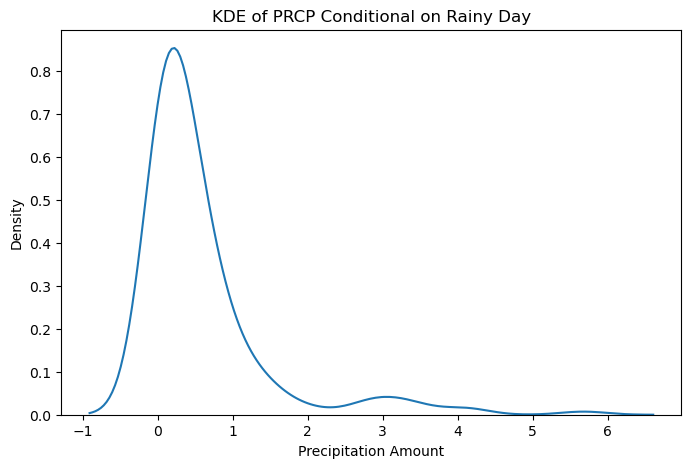

In [124]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=filtered_df, x='PRCP')

plt.title('KDE of PRCP Conditional on Rainy Day')
plt.xlabel('Precipitation Amount')
plt.ylabel('Density')
plt.show()

**Describe one way of making your model better for forecasting and simulation the weather.**

*One way of making this model better for forecasting and simulating weather is adding more states to the rainy column. Maybe have a no rain (0), light rain (1), medium rain (2), heavy rain (3) range so that the amount of rain that falls can be better forecasted.*

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [125]:
import pickle

In [126]:
with open ('taxicab.pkl', 'rb') as f: 
    data = pickle.load(f)

len(data)

1000

**For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.**

In [127]:
states = set(data[0])

for i in range(1, len(data)): 
    new_trip = data[i]
    new_states = set(new_trip) 
    states = states.union(new_states)

states = list(states)
states


['Chinatown',
 "Randall's Island",
 'East Village',
 'Kips Bay',
 'Washington Heights',
 'Central Park',
 'Harlem',
 'NoHo',
 'Marble Hill',
 'Inwood',
 'Greenwich Village',
 'SoHo',
 'Morningside Heights',
 'Tribeca',
 'Chelsea',
 'Little Italy',
 'Roosevelt Island',
 'Flatiron District',
 'Upper West Side',
 'Financial District',
 'Upper East Side',
 'Two Bridges',
 'Civic Center',
 'Ellis Island',
 'Outside Manhattan',
 'Theater District',
 "Hell's Kitchen",
 'Battery Park City',
 'Governors Island',
 'Nolita',
 'Midtown',
 'East Harlem',
 'Lower East Side',
 'Gramercy',
 'Stuyvesant Town',
 'West Village',
 'Murray Hill',
 'Liberty Island']

**Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?**

In [128]:
tr_counts = np.zeros( (len(states), len(states)) )

# this is kinda like the chord problem bc you are 
# jumping around -- each trip is like a song 


for trip in data: 
    seq = np.array(trip)
    for t in range(1, len(seq)): # starts at 1 because we are doing a markov chain (we are doing t - 1 later in the loop)
        x_tm1 = seq[t-1] # previous state
        x_t = seq[t] # current state
        index_from = states.index(x_tm1) # look up which state 
        index_to = states.index(x_t)
        tr_counts[index_to, index_from] += 1


# sets are kinda crazy under the hood -- shoving stuff wherever it can go 
# the list(states) isn't deterministic 

print('Transition Counts: \n', tr_counts)

Transition Counts: 
 [[1.39800e+04 2.00000e+00 6.65200e+03 ... 3.43700e+03 1.39300e+03
  0.00000e+00]
 [9.00000e+00 6.39000e+02 7.50000e+01 ... 3.30000e+01 7.30000e+01
  0.00000e+00]
 [8.57500e+03 1.90000e+01 2.37311e+05 ... 3.28360e+04 2.22170e+04
  0.00000e+00]
 ...
 [3.36900e+03 2.30000e+01 3.11250e+04 ... 2.42469e+05 1.08090e+04
  0.00000e+00]
 [1.53400e+03 3.80000e+01 2.58720e+04 ... 1.24550e+04 1.28013e+05
  0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 ... 0.00000e+00 0.00000e+00
  0.00000e+00]]


In [129]:
row_sums = tr_counts.sum(axis=1, keepdims=True)
random_pr = row_sums/np.sum(row_sums)
print('\nState proportions: ', random_pr)

# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, row_sums, 
                            out=np.zeros_like(tr_counts), 
                            where=row_sums!=0)
print('\nTransition Proportions:\n', tr_pr)


State proportions:  [[4.61071223e-03]
 [1.56908713e-04]
 [3.86999684e-02]
 [2.21133718e-02]
 [3.15864250e-03]
 [1.61187448e-02]
 [9.45728834e-03]
 [7.59162938e-03]
 [2.14698849e-05]
 [6.23279905e-04]
 [2.22216358e-02]
 [2.39782033e-02]
 [7.08571527e-03]
 [1.77960523e-02]
 [8.61531610e-02]
 [1.68061730e-03]
 [3.48831193e-04]
 [1.72139702e-02]
 [7.85410634e-02]
 [1.92312248e-02]
 [1.21838897e-01]
 [4.52391815e-04]
 [2.52186227e-03]
 [1.30648387e-07]
 [1.02949231e-01]
 [3.80646253e-02]
 [5.33186955e-02]
 [9.98297390e-03]
 [5.22593548e-07]
 [4.63266116e-03]
 [1.67749437e-01]
 [1.37986036e-02]
 [1.61379501e-02]
 [2.18506379e-02]
 [4.84644547e-03]
 [3.65537638e-02]
 [2.84986375e-02]
 [4.35494623e-08]]

Transition Proportions:
 [[1.32044997e-01 1.88905576e-05 6.28299944e-02 ... 3.24634232e-02
  1.31572733e-02 0.00000000e+00]
 [2.49791840e-03 1.77352206e-01 2.08159867e-02 ... 9.15903414e-03
  2.02608937e-02 0.00000000e+00]
 [9.64953345e-03 2.13808904e-05 2.67048447e-01 ... 3.69506799e-02
  2.

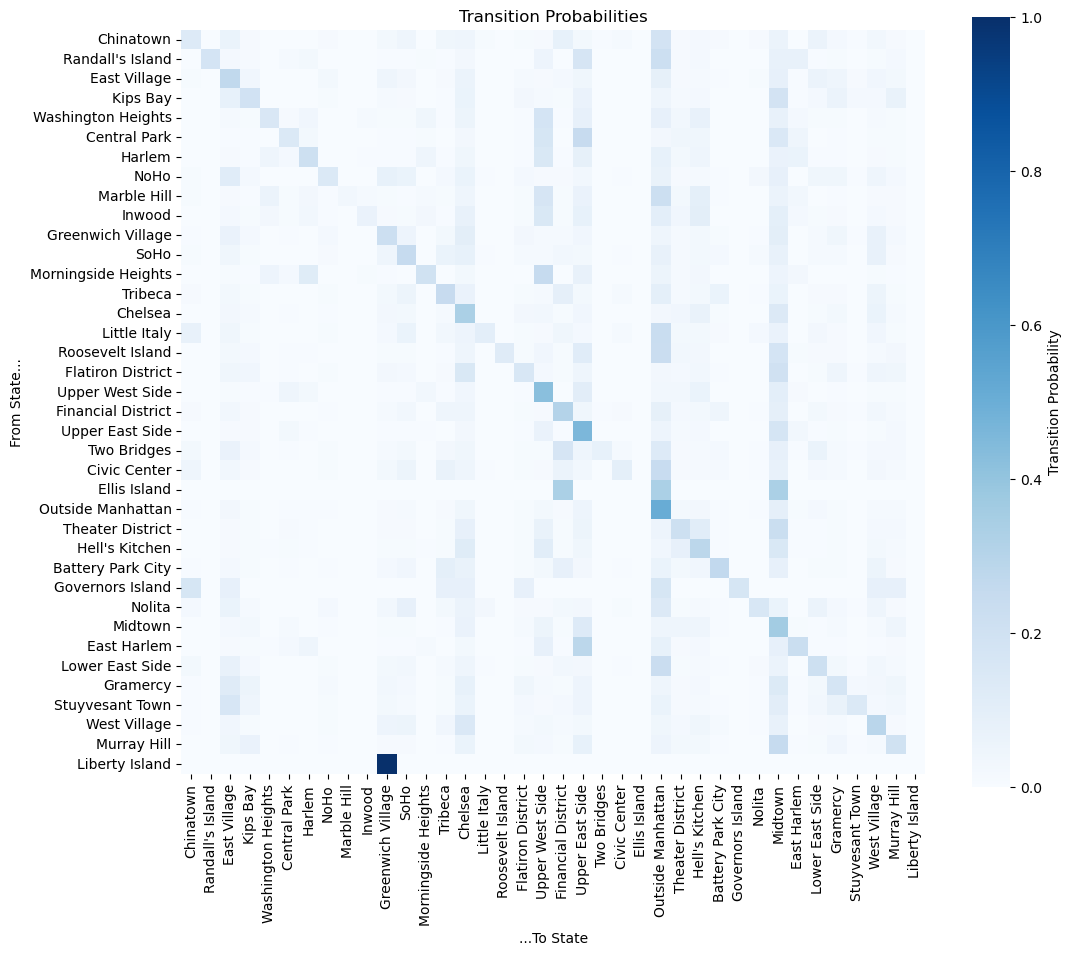

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(tr_pr, 
            cmap='Blues',    
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

*The most common routes are Liberty Island to Greenwich Village, Outside Manhattan to Outside Manhattan, Upper East Side to Upper East Side.*

**Explain why taxicabs are most likely order 1, and not 2 or more.**

*Taxicabs are most likely order 1, and not 2 or more because a taxicab's next state/destination really only depends on its current state/destination. A neighborhood that the cab was in 2 or more trips ago doesn't really affect where it will go next.*

**Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips**

In [131]:
np.random.seed(100) 

initial_state = "Hell's Kitchen"
current_state_index = states.index(initial_state) 
print(f'Initial state: {initial_state}') 

n_sim = 2
simulation = [initial_state]

for t in range(n_sim - 1): 
    pr_t = tr_pr[current_state_index, :] 
    next_state_index = np.random.choice(len(states), p=pr_t) 
    current_state_index = next_state_index
    simulation.append(states[current_state_index]) 

print(simulation)

Initial state: Hell's Kitchen
["Hell's Kitchen", "Hell's Kitchen"]


In [132]:
np.random.seed(100) 


initial_state = "Hell's Kitchen"
current_state_index = states.index(initial_state) 
print(f'Initial state: {initial_state}') 

n_sim = 3
simulation = [initial_state]

for t in range(n_sim - 1): 
    pr_t = tr_pr[current_state_index, :] 
    next_state_index = np.random.choice(len(states), p=pr_t) 
    current_state_index = next_state_index
    simulation.append(states[current_state_index]) 

print(simulation)


Initial state: Hell's Kitchen
["Hell's Kitchen", "Hell's Kitchen", 'Upper West Side']


In [133]:
np.random.seed(100) 

initial_state = "Hell's Kitchen"
current_state_index = states.index(initial_state) 
print(f'Initial state: {initial_state}') 

n_sim = 5
simulation = [initial_state]


for t in range(n_sim - 1): 
    pr_t = tr_pr[current_state_index, :] 
    next_state_index = np.random.choice(len(states), p=pr_t) 
    current_state_index = next_state_index
    simulation.append(states[current_state_index]) 

print(simulation)

Initial state: Hell's Kitchen
["Hell's Kitchen", "Hell's Kitchen", 'Upper West Side', 'Upper West Side', "Hell's Kitchen"]


In [134]:
np.random.seed(100) 


initial_state = "Hell's Kitchen"
current_state_index = states.index(initial_state) 
print(f'Initial state: {initial_state}') 

n_sim = 10
simulation = [initial_state]


for t in range(n_sim - 1):
    pr_t = tr_pr[current_state_index, :] 
    next_state_index = np.random.choice(len(states), p=pr_t) 
    current_state_index = next_state_index
    simulation.append(states[current_state_index]) 

print(simulation)

Initial state: Hell's Kitchen
["Hell's Kitchen", "Hell's Kitchen", 'Upper West Side', 'Upper West Side', "Hell's Kitchen", 'East Village', 'East Village', 'Outside Manhattan', 'Nolita', 'Greenwich Village']


**Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?**

In [135]:
np.random.seed(100)

initial_state = 'Upper West Side' 
state_index = states.index(initial_state)


density = np.zeros(len(states))
density[state_index] = 1

n_sim = 5

forecast = []
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density)


history_array = np.array(forecast)
average_distribution = np.mean(history_array, axis=0)


print(average_distribution)

[0.04347063 0.07529427 0.04488803 0.05076789 0.12798704 0.12233203
 0.12331931 0.04469235 0.11809223 0.11370221 0.04845428 0.04542972
 0.16621269 0.04631656 0.06033599 0.04417427 0.06357967 0.0545867
 0.20253743 0.04536811 0.08411353 0.04365989 0.04509887 0.04358468
 0.05495132 0.08272375 0.09802818 0.05006609 0.03429097 0.04343483
 0.07452137 0.09313523 0.04376537 0.04837234 0.04673151 0.05113152
 0.05516034 0.03461309]


In [136]:
distribution_series = pd.Series(average_distribution, index=states)


sorted_series = distribution_series.sort_values(ascending=False)

print(sorted_series)


Upper West Side        0.202537
Morningside Heights    0.166213
Washington Heights     0.127987
Harlem                 0.123319
Central Park           0.122332
Marble Hill            0.118092
Inwood                 0.113702
Hell's Kitchen         0.098028
East Harlem            0.093135
Upper East Side        0.084114
Theater District       0.082724
Randall's Island       0.075294
Midtown                0.074521
Roosevelt Island       0.063580
Chelsea                0.060336
Murray Hill            0.055160
Outside Manhattan      0.054951
Flatiron District      0.054587
West Village           0.051132
Kips Bay               0.050768
Battery Park City      0.050066
Greenwich Village      0.048454
Gramercy               0.048372
Stuyvesant Town        0.046732
Tribeca                0.046317
SoHo                   0.045430
Financial District     0.045368
Civic Center           0.045099
East Village           0.044888
NoHo                   0.044692
Little Italy           0.044174
Lower Ea

*When starting in the Upper West Side, the neighborhood that cabs seemed to spend the most time in is the Upper West Side.*